In [19]:
import pandas as pd
df = pd.read_csv(r'C:\Users\LENOVO\Downloads\it_company_employee_dataset.csv')
df.head()
df.tail()

,Employee_ID,Department,Experience_Years,Salary,Performance_Score,Projects_Completed,Location
995,996,HR,12,37069,4,13,Bangalore
996,997,IT,2,27531,5,2,Hyderabad
997,998,IT,9,57051,3,9,Pune
998,999,Sales,2,27736,4,2,Hyderabad
999,1000,Finance,6,27710,1,11,Chennai


In [20]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         1000 non-null   int64 
 1   Department          1000 non-null   object
 2   Experience_Years    1000 non-null   int64 
 3   Salary              1000 non-null   int64 
 4   Performance_Score   1000 non-null   int64 
 5   Projects_Completed  1000 non-null   int64 
 6   Location            1000 non-null   object
dtypes: int64(5), object(2)
memory usage: 54.8+ KB


Employee_ID           0
Department            0
Experience_Years      0
Salary                0
Performance_Score     0
Projects_Completed    0
Location              0
dtype: int64

1.AVERAGE SALARY BY DEPARTMENT


In [42]:

df.groupby("Department")["Salary"].mean()

Department
Finance    69911.615789
HR         66753.115789
IT         70689.500000
Sales      71939.174757
Support    70813.156863
Name: Salary, dtype: float64


2.TOP 10 HIGH PERFOMING EMPLOYEES

In [24]:
df.sort_values(by="Performance_Score", ascending=False).head(10)

,Employee_ID,Department,Experience_Years,Salary,Performance_Score,Projects_Completed,Location
12,13,Support,14,57412,5,15,Chennai
15,16,HR,5,80315,5,4,Bangalore
986,987,Support,13,35078,5,2,Bangalore
996,997,IT,2,27531,5,2,Hyderabad
988,989,Finance,1,25105,5,12,Pune
3,4,Support,3,48380,5,12,Chennai
430,431,HR,7,45592,5,9,Hyderabad
441,442,Support,1,119983,5,13,Kolkata
447,448,IT,14,49301,5,8,Chennai
389,390,HR,0,51007,5,15,Bangalore



3.EMPLOYEES WITH LOW PERFORMANCE

In [25]:
df[df["Performance_Score"] <= 2]

,Employee_ID,Department,Experience_Years,Salary,Performance_Score,Projects_Completed,Location
1,2,Support,11,90316,1,15,Pune
5,6,HR,7,90326,2,10,Bangalore
9,10,Support,9,95717,2,15,Kolkata
10,11,Sales,0,36082,2,3,Kolkata
11,12,Finance,11,20661,1,2,Chennai
...,...,...,...,...,...,...,...
985,986,Finance,9,49309,2,5,Kolkata
987,988,Sales,10,76614,2,2,Kolkata
990,991,HR,11,22839,2,15,Bangalore
991,992,Finance,6,88920,2,5,Kolkata



4.EXPERIENCE VS SALARY ANALYSIS

In [27]:
df.groupby("Experience_Years")["Salary"].mean()

Experience_Years
0     69626.236111
1     67399.648649
2     65712.969231
3     67503.592593
4     67504.688525
5     71570.153846
6     74354.939394
7     73342.304348
8     72003.228571
9     71181.753846
10    74611.430556
11    69882.469697
12    72289.930556
13    68421.181818
14    64275.841270
Name: Salary, dtype: float64


5.DEPARTMENT WISE EMPLOYEES COUNT

In [28]:
df["Department"].value_counts

<bound method IndexOpsMixin.value_counts of 0        Sales
1      Support
2      Finance
3      Support
4      Support
        ...   
995         HR
996         IT
997         IT
998      Sales
999    Finance
Name: Department, Length: 1000, dtype: object>


6.TOP PERFORMING DEPARTMENT

In [30]:
df.groupby("Department")["Performance_Score"].mean().sort_values(ascending=False)

Department
IT         3.138095
Finance    3.089474
HR         2.989474
Support    2.950980
Sales      2.941748
Name: Performance_Score, dtype: float64


7.EMPLOYEES WITH SALARY BUT LOW PERFORMANCE

In [31]:
df[(df["Salary"] > 8000 & (df["Performance_Score"]<=2))]

,Employee_ID,Department,Experience_Years,Salary,Performance_Score,Projects_Completed,Location
0,1,Sales,11,72579,4,16,Bangalore
1,2,Support,11,90316,1,15,Pune
2,3,Finance,3,103847,4,10,Chennai
3,4,Support,3,48380,5,12,Chennai
4,5,Support,4,22356,4,17,Kolkata
...,...,...,...,...,...,...,...
995,996,HR,12,37069,4,13,Bangalore
996,997,IT,2,27531,5,2,Hyderabad
997,998,IT,9,57051,3,9,Pune
998,999,Sales,2,27736,4,2,Hyderabad



8.LOCATION WISE SALARY ANALYSIS

In [33]:
df.groupby("Location")["Salary"].mean()

Location
Bangalore    70767.064171
Chennai      70282.874372
Hyderabad    69753.775510
Kolkata      68121.416667
Pune         71637.371287
Name: Salary, dtype: float64


9.CORRELAIION ANALYSIS

In [34]:
df.corr(numeric_only=True)

,Employee_ID,Experience_Years,Salary,Performance_Score,Projects_Completed
Employee_ID,1.000000,0.073551,-0.024249,0.006418,0.024292
Experience_Years,0.073551,1.000000,0.017426,-0.048256,0.014855
Salary,-0.024249,0.017426,1.000000,-0.009994,-0.017350
Performance_Score,0.006418,-0.048256,-0.009994,1.000000,-0.004727
Projects_Completed,0.024292,0.014855,-0.017350,-0.004727,1.000000



10.ADD NEW COLUMN (BONUS REAL TASK)

In [36]:
df["Salary_Level"]= pd.cut(df["Salary"],bins=[0,40000,80000,120000],labels=["Low", "Medium", "High"])

11. HOW CAN WE ASSIGN BONUS TO EMPLOYEES BASED ON THEIR PERFORMANCE SCORE?

In [40]:
import numpy as np

df["Bonus"] = np.where(df["Performance_Score"] >= 4,
                       df["Salary"] * 0.10,
                       df["Salary"] * 0.05)

In [41]:
print(df)

     Employee_ID Department  Experience_Years  Salary  Performance_Score  \
0              1      Sales                11   72579                  4   
1              2    Support                11   90316                  1   
2              3    Finance                 3  103847                  4   
3              4    Support                 3   48380                  5   
4              5    Support                 4   22356                  4   
..           ...        ...               ...     ...                ...   
995          996         HR                12   37069                  4   
996          997         IT                 2   27531                  5   
997          998         IT                 9   57051                  3   
998          999      Sales                 2   27736                  4   
999         1000    Finance                 6   27710                  1   

     Projects_Completed   Location Salary_Level     Bonus  
0                    16  Ba

12. SORT BY PERFORMANCE

In [14]:
import pandas as pd

df = pd.read_csv(r'C:\Users\LENOVO\Downloads\it_company_employee_dataset.csv')
df.sort_values(by="Performance_Score", ascending=False)

,Employee_ID,Department,Experience_Years,Salary,Performance_Score,Projects_Completed,Location
12,13,Support,14,57412,5,15,Chennai
15,16,HR,5,80315,5,4,Bangalore
986,987,Support,13,35078,5,2,Bangalore
996,997,IT,2,27531,5,2,Hyderabad
988,989,Finance,1,25105,5,12,Pune
...,...,...,...,...,...,...,...
26,27,Finance,4,20956,1,10,Hyderabad
980,981,Finance,14,62963,1,3,Chennai
11,12,Finance,11,20661,1,2,Chennai
1,2,Support,11,90316,1,15,Pune


13.LINE PLOT


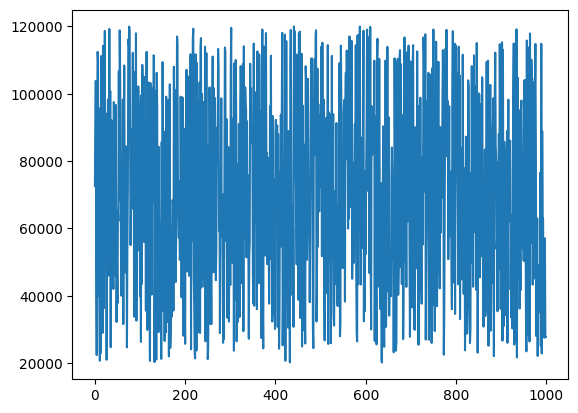

In [15]:
import matplotlib.pyplot as plt    
plt.plot(df["Salary"])
plt.show()

13. BAR CHART

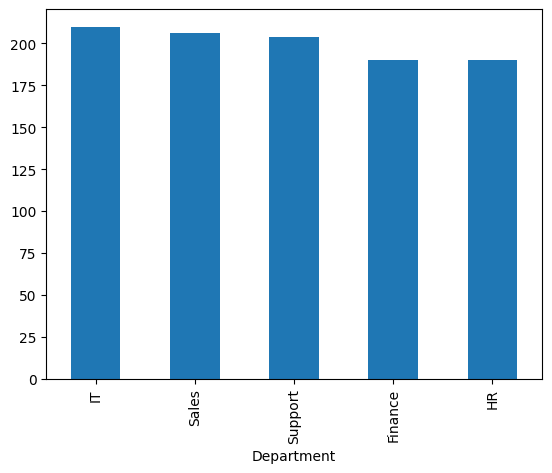

In [16]:
df["Department"].value_counts().plot(kind="bar")
plt.show()

14.HISTOGRAM

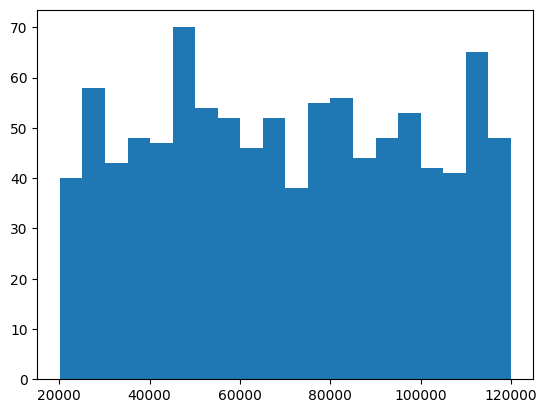

In [17]:
plt.hist(df["Salary"], bins=20)
plt.show()

15. SCATTER PLOT

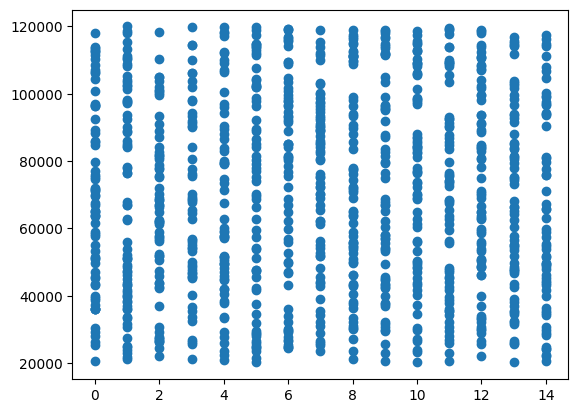

In [18]:
plt.scatter(df["Experience_Years"], df["Salary"])
plt.show()

16.BOX PLOT

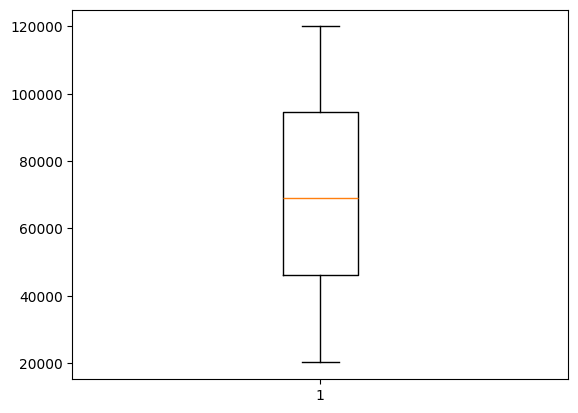

In [19]:
plt.boxplot(df["Salary"])
plt.show()